In [1]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import StepLR
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Dataset
from scipy.io import loadmat
import numpy as np
from PIL import Image
from glob import glob

### Load dataset

In [2]:
# === Load dataset with .mat parsing ===
class ShanghaiDataset(Dataset):
    def __init__(self, image_dir, gt_dir, transform=None, return_raw=False):
        self.image_paths = sorted(glob(os.path.join(image_dir, '*.jpg')))
        self.gt_paths = sorted(glob(os.path.join(gt_dir, 'GT_*.mat')))
        self.transform = transform
        self.return_raw = return_raw

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        raw_image = image.copy()  # keep for visualization

        if self.transform:
            image = self.transform(image)

        gt = loadmat(self.gt_paths[idx])
        count = len(gt['image_info'][0, 0][0, 0][0])

        if self.return_raw:
            return image, torch.tensor([count], dtype=torch.float32), raw_image
        else:
            return image, torch.tensor([count], dtype=torch.float32)

In [3]:
# === Augment-heavy Train Transform ===
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# === Clean Test Transform ===
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [4]:
def custom_collate_fn(batch):
    imgs, targets, raws = zip(*batch)  # unzip the list of tuples
    return torch.stack(imgs), torch.stack(targets), raws

In [5]:
# === Dataloader ===
dataset_root = "/home/wins057/Documents/Projects/python-for-dl-homework/week10/dataset/ShanghaiTech_Crowd_Counting_Dataset"
# ShanghaiTech Part A
train_images = os.path.join(dataset_root, "part_A_final/train_data/images")
train_ground_truth = os.path.join(dataset_root, "part_A_final/train_data/ground_truth")
test_images = os.path.join(dataset_root, "part_A_final/test_data/images")
test_ground_truth = os.path.join(dataset_root, "part_A_final/test_data/ground_truth")

# Create dataset and dataloader
trainset = ShanghaiDataset(train_images, train_ground_truth, train_transform)
train_loader = DataLoader(trainset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
testset = ShanghaiDataset(test_images, test_ground_truth, test_transform, return_raw=True)
test_loader = DataLoader(testset, batch_size=1, shuffle=False, collate_fn=custom_collate_fn, num_workers=4, pin_memory=True, persistent_workers=True)

# Train and test dataset sizes
print("Train samples:", len(train_loader.dataset))
print("Test samples:", len(test_loader.dataset))

Train samples: 300
Test samples: 182


### Model Selection

In [6]:
import torch
import torch.nn as nn
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet18, ResNet18_Weights,
    mobilenet_v2, MobileNet_V2_Weights,
    shufflenet_v2_x0_5, ShuffleNet_V2_X0_5_Weights,
    mobilenet_v3_small, MobileNet_V3_Small_Weights,
    mnasnet0_5, MNASNet0_5_Weights
)

# Mapping between model names and their constructors + final layer names
model_configs = {
    'efficientnet_b0': (efficientnet_b0, EfficientNet_B0_Weights.DEFAULT, 'classifier'),
    'resnet18': (resnet18, ResNet18_Weights.DEFAULT, 'fc'),
    'mobilenet_v2': (mobilenet_v2, MobileNet_V2_Weights.DEFAULT, 'classifier'),
    'shufflenet_v2_x0_5': (shufflenet_v2_x0_5, ShuffleNet_V2_X0_5_Weights.DEFAULT, 'fc'),
    'mobilenet_v3_small': (mobilenet_v3_small, MobileNet_V3_Small_Weights.DEFAULT, 'classifier'),
    'mnasnet0_5': (mnasnet0_5, MNASNet0_5_Weights.DEFAULT, 'classifier')
}

def get_model(name):
    if name not in model_configs:
        raise ValueError(f"Model '{name}' is not supported.")
    
    constructor, weights, head = model_configs[name]
    model = constructor(weights=weights)

    if head == 'classifier':
        if name == 'efficientnet_b0':
            model.classifier[-1] = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(model.classifier[-1].in_features, 1)
            )
        else:
            model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 1)
    elif head == 'fc':
        model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, 1)
        )

    return model

### Train

In [7]:
def save_checkpoint(model, optimizer, epoch, path):
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch
    }, path)

In [8]:
def count_parameters(model):
    """ Count the number of trainable parameters in the model.
    Args:
        model (nn.Module): The model to count parameters for.
    Returns:
        int: The number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [9]:
from torch.utils.tensorboard import SummaryWriter
from torchsummary import summary
from torch.nn.utils import clip_grad_norm_
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train_and_validate(model_name, num_epochs=150, lr=0.001, ckpt_dir="checkpoints", patience=30, log_dir="runs/train"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(ckpt_dir, exist_ok=True)
    writer = SummaryWriter(log_dir=log_dir)

    model = get_model(model_name).to(device)
    criterion = nn.SmoothL1Loss(beta=1.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_val_mae = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0

    summary(model, (3, 256, 256))

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_mae = 0.0
        for imgs, targets in train_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            preds = model(imgs).view(-1)
            targets = targets.view(-1)
            loss = criterion(preds, targets)
            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping
            clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_mae += torch.abs(preds - targets).sum().item()
        train_mae /= len(train_loader.dataset)

        model.eval()
        val_mae = 0.0
        with torch.no_grad():
            for imgs, targets, _ in test_loader:
                imgs, targets = imgs.to(device), targets.to(device)
                preds = model(imgs).view(-1)
                val_mae += torch.abs(preds - targets).sum().item()
        val_mae /= len(test_loader.dataset)

        # Scheduler step based on validation MAE
        scheduler.step(val_mae)

        # TensorBoard logging
        writer.add_scalar(f"{model_name}/Train_MAE", train_mae, epoch)
        writer.add_scalar(f"{model_name}/Val_MAE", val_mae, epoch)

        log = (f"[{model_name}] Epoch {epoch:03d}/{num_epochs} | "
               f"Train MAE: {train_mae:.2f} | Val MAE: {val_mae:.2f} | "
               f"LR: {optimizer.param_groups[0]['lr']:.1e}")

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_epoch = epoch
            epochs_without_improvement = 0
            best_path = os.path.join(ckpt_dir, f"{model_name}_best.pth")
            save_checkpoint(model, optimizer, epoch, best_path)
            log += " ✅ Model saved"
        else:
            epochs_without_improvement += 1

        print(log)

        if epochs_without_improvement >= patience:
            print(f"⏹️  Early stopping at epoch {epoch} (no improvement in {patience} epochs)")
            break

    writer.close()
    print(f"\n🎯 Training finished. Best model from epoch {best_epoch} with Val MAE: {best_val_mae:.2f}")
    print(f"📦 Total parameters in {model_name}: {count_parameters(model):,}")

In [10]:
train_and_validate("efficientnet_b0", num_epochs=300, lr=0.001, patience=40)

Layer (type:depth-idx)                        Output Shape              Param #
├─Sequential: 1-1                             [-1, 1280, 8, 8]          --
|    └─Conv2dNormActivation: 2-1              [-1, 32, 128, 128]        --
|    |    └─Conv2d: 3-1                       [-1, 32, 128, 128]        864
|    |    └─BatchNorm2d: 3-2                  [-1, 32, 128, 128]        64
|    |    └─SiLU: 3-3                         [-1, 32, 128, 128]        --
|    └─Sequential: 2-2                        [-1, 16, 128, 128]        --
|    |    └─MBConv: 3-4                       [-1, 16, 128, 128]        1,448
|    └─Sequential: 2-3                        [-1, 24, 64, 64]          --
|    |    └─MBConv: 3-5                       [-1, 24, 64, 64]          6,004
|    |    └─MBConv: 3-6                       [-1, 24, 64, 64]          10,710
|    └─Sequential: 2-4                        [-1, 40, 32, 32]          --
|    |    └─MBConv: 3-7                       [-1, 40, 32, 32]          15,350
|    

In [11]:
train_and_validate("shufflenet_v2_x0_5", num_epochs=300, lr=0.001, patience=40)

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 24, 128, 128]        --
|    └─Conv2d: 2-1                       [-1, 24, 128, 128]        648
|    └─BatchNorm2d: 2-2                  [-1, 24, 128, 128]        48
|    └─ReLU: 2-3                         [-1, 24, 128, 128]        --
├─MaxPool2d: 1-2                         [-1, 24, 64, 64]          --
├─Sequential: 1-3                        [-1, 48, 32, 32]          --
|    └─InvertedResidual: 2-4             [-1, 48, 32, 32]          --
|    |    └─Sequential: 3-1              [-1, 24, 32, 32]          888
|    |    └─Sequential: 3-2              [-1, 24, 32, 32]          1,512
|    └─InvertedResidual: 2-5             [-1, 48, 32, 32]          --
|    |    └─Sequential: 3-3              [-1, 24, 32, 32]          1,512
|    └─InvertedResidual: 2-6             [-1, 48, 32, 32]          --
|    |    └─Sequential: 3-4              [-1, 24, 32, 32]          1,512
|   

### Evaluation

In [12]:
def test_model(model, test_loader, device):
    model.eval()
    total_mae = 0.0
    with torch.no_grad():
        for imgs, targets,_ in test_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            preds = model(imgs).view(-1)
            targets = targets.view(-1)
            total_mae += torch.abs(preds - targets).sum().item()
    return total_mae / len(test_loader.dataset)

In [13]:
def load_best_model(model_name, device, ckpt_dir="checkpoints"):
    model = get_model(model_name).to(device)
    ckpt_path = os.path.join(ckpt_dir, f"{model_name}_best.pth")
    checkpoint = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def predict_on_test_set(model, test_loader, device, max_images=4):
    model.eval()
    predictions, ground_truth = [], []
    raw_images, preds_to_plot, gts_to_plot = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            # Check if raw images are included
            if len(batch) == 3:
                imgs, targets, raws = batch
            else:
                imgs, targets = batch
                raws = [None] * len(imgs)

            imgs, targets = imgs.to(device), targets.to(device)
            preds = model(imgs).view(-1)

            predictions.extend(preds.cpu().numpy().tolist())
            ground_truth.extend(targets.cpu().numpy().tolist())

            # Store raw images for display
            if len(raw_images) < max_images:
                for i in range(min(len(imgs), max_images - len(raw_images))):
                    raw_img = raws[i]
                    if not isinstance(raw_img, Image.Image):
                        try:
                            raw_img = Image.fromarray(raw_img)
                        except Exception:
                            continue
                    raw_images.append(raw_img)
                    preds_to_plot.append(preds[i].item())
                    gts_to_plot.append(targets[i].item())

    # === Flatten and round predictions ===
    predictions = np.array(predictions).flatten().tolist()
    ground_truth = np.array(ground_truth).flatten().tolist()
    predictions = [round(p, 2) for p in predictions]
    ground_truth = [round(gt, 2) for gt in ground_truth]

    # === Plot raw images with prediction/GT ===
    if raw_images:
        fig, axs = plt.subplots(1, len(raw_images), figsize=(16, 4))
        for i, ax in enumerate(axs):
            ax.imshow(raw_images[i])
            ax.axis("off")
            ax.set_title(f"Pred: {preds_to_plot[i]:.1f} | GT: {gts_to_plot[i]:.1f}")
        plt.tight_layout()
        plt.show()

    return predictions, ground_truth

✅ Test MAE: 116.54


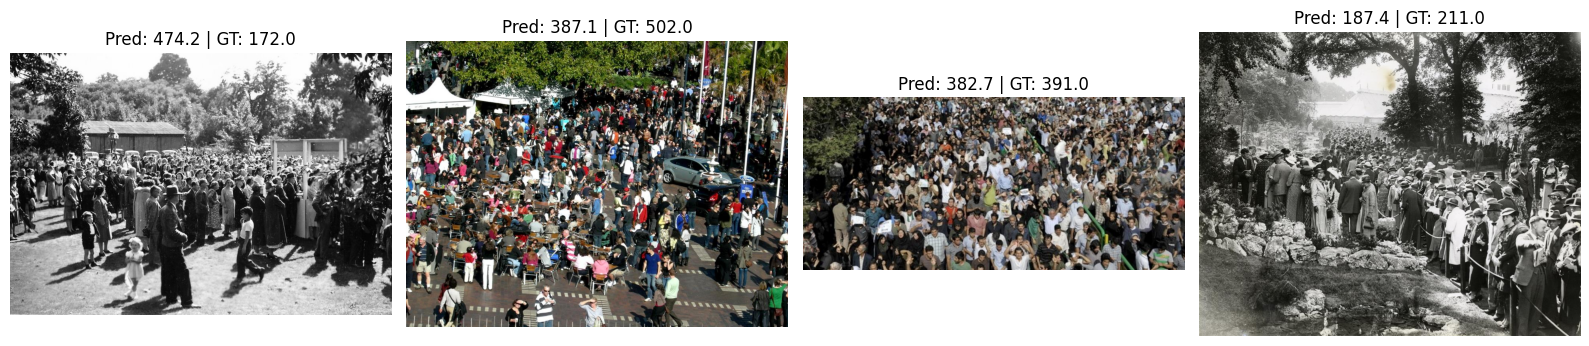

✅ Sample Ground Truth: [172.0, 502.0, 391.0, 211.0, 223.0]
🔍 Sample predictions: [474.21, 387.15, 382.73, 187.4, 260.17]


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load best model
model = load_best_model("shufflenet_v2_x0_5", device)

# Evaluate MAE
mae = test_model(model, test_loader, device)
print(f"✅ Test MAE: {mae:.2f}")

# Get predictions
preds, gts = predict_on_test_set(model, test_loader, device, max_images=4)
# Print five predictions
print("✅ Sample Ground Truth:", gts[:5])
print("🔍 Sample predictions:", preds[:5])

### TensorBoard

In [16]:
import subprocess
import time
import webbrowser

def start_tensorboard(logdir="runs", port=6006):
    """
    Starts TensorBoard as a background process and opens it in your default browser.
    Returns the process handle so you can terminate it later.
    """
    tb_cmd = [
        "tensorboard",
        f"--logdir={logdir}",
        f"--port={port}",
        "--host=localhost"
    ]
    
    # Start the process
    print(f"Starting TensorBoard on port {port}...")
    process = subprocess.Popen(tb_cmd)
    
    # Give it a second to get going
    time.sleep(2)
    
    # Open in browser automatically
    url = f"http://localhost:{port}"
    print(f"Opening {url} in your default browser...")
    webbrowser.open(url)
    
    return process


def stop_tensorboard(process):
    """
    Stops the TensorBoard process started by `start_tensorboard()`.
    """
    print("Stopping TensorBoard...")
    process.terminate()  # or process.kill()

In [17]:
process = start_tensorboard(logdir="runs", port=6009)

Starting TensorBoard on port 6009...


TensorFlow installation not found - running with reduced feature set.

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

TensorBoard 2.19.0 at http://localhost:6009/ (Press CTRL+C to quit)


Opening http://localhost:6009 in your default browser...


In [18]:
# stop_tensorboard(process)
# Uncomment the line below to stop TensorBoard when you're done